# MAML Model

Using device: cpu
Upload your 3 CSV files:
1. preprocessed_augmented_dataset_scaled.csv
2. validation_set_scaled.csv
3. test_set_scaled.csv


Saving test_set_scaled.csv to test_set_scaled.csv
Saving validation_set_scaled.csv to validation_set_scaled.csv
Saving preprocessed_augmented_dataset_scaled.csv to preprocessed_augmented_dataset_scaled.csv
Training file:   preprocessed_augmented_dataset_scaled.csv
Validation file: validation_set_scaled.csv
Test file:       test_set_scaled.csv
Number of features: 19
Number of classes: 10

MAML PRETRAINING


Pretrain Epoch 1/3:   0%|          | 0/782 [00:00<?, ?it/s]

Pretrain Epoch 2/3:   0%|          | 0/782 [00:00<?, ?it/s]

Pretrain Epoch 3/3:   0%|          | 0/782 [00:00<?, ?it/s]

...

Epoch 1/2 | Train Acc: 0.6718 | Val Acc: 0.7937 | LR: 0.000025
  New best validation accuracy: 0.7937


Fine-tune Epoch 2/2:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2/2 | Train Acc: 0.7844 | Val Acc: 0.8000 | LR: 0.000000
  New best validation accuracy: 0.8000


Evaluating with TTA:   0%|          | 0/3 [00:00<?, ?it/s]


FINAL MAML PERFORMANCE
Accuracy:  0.8212 (82.12%)
Precision: 0.8057
Recall:    0.8212
F1 Score:  0.8084


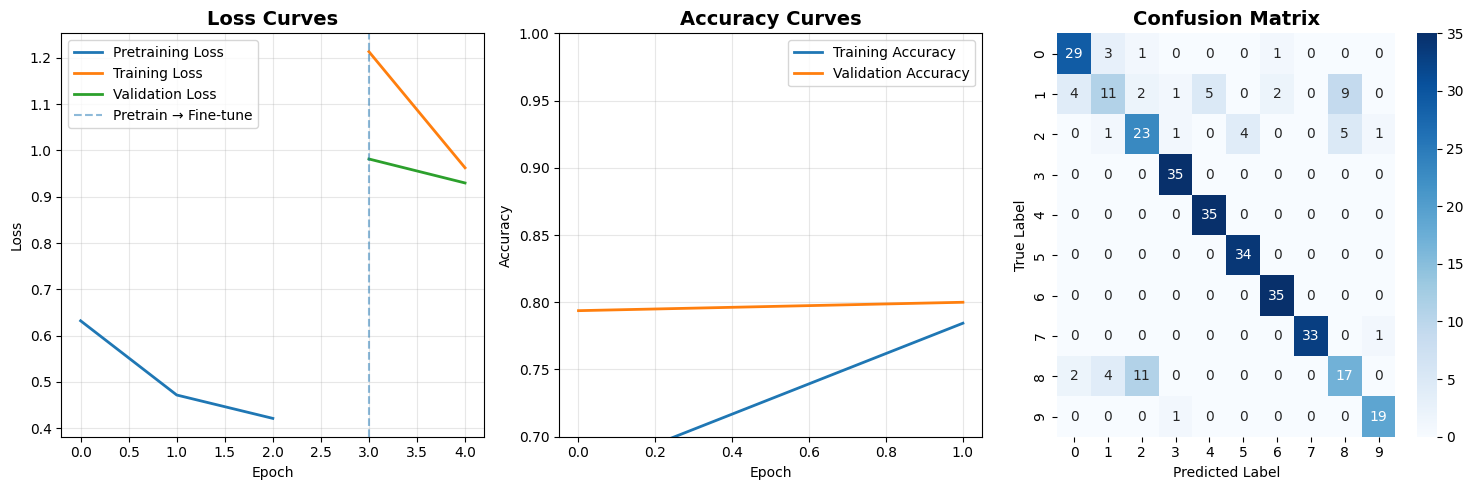


Model saved to: /content/maml_final_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL MAML (MODEL‑AGNOSTIC META‑LEARNING) MODEL
# Optimized via comprehensive ablation studies

# !pip -q install torch torchvision torchaudio pandas numpy scikit-learn tqdm matplotlib

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm
from google.colab import files
warnings.filterwarnings('ignore')

# ============================================================
# 1. Configuration (Optimal from ablation)
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)

# Data settings
TARGET_COL = "fault_encoded"
MASK_RATIO = 0.20
REPLACE_WITH_MASK = 0.8
REPLACE_WITH_RANDOM = 0.1
REPLACE_WITH_SAME = 0.1

# Training settings
BATCH_SIZE = 128
EPOCHS_PRETRAIN = 3
EPOCHS_FINETUNE = 2
PATIENCE = 5
LR_PRETRAIN = 1e-4
LR_FINETUNE = 5e-5
WEIGHT_DECAY = 5e-4

# Model architecture
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 4
DROPOUT = 0.3

# Regularization
USE_LABEL_SMOOTHING = 0.1          # label smoothing factor (kept)
USE_GRADIENT_CLIPPING = 5.0        # gradient norm clip (kept)
USE_DROPOUT_ENSEMBLE = True        # TTA with dropout (kept)
NUM_PASSES = 15                    # number of TTA passes (kept)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# 2. Upload Data (Colab)
# ============================================================
print("Upload your 3 CSV files:")
print("1. preprocessed_augmented_dataset_scaled.csv")
print("2. validation_set_scaled.csv")
print("3. test_set_scaled.csv")
uploaded = files.upload()
uploaded_names = list(uploaded.keys())

def choose_file(kind):
    lower_names = [name.lower() for name in uploaded_names]
    if kind == "train":
        keywords = ["augmented", "train", "training", "preprocessed"]
    elif kind == "val":
        keywords = ["validation", "val"]
    elif kind == "test":
        keywords = ["test"]
    else:
        keywords = []
    candidates = [orig for orig, low in zip(uploaded_names, lower_names) if any(k in low for k in keywords)]
    if len(candidates) == 1:
        return candidates[0]
    print(f"Could not automatically choose the {kind} file. Available: {uploaded_names}")
    idx = int(input(f"Enter the index of the {kind} file: "))
    return uploaded_names[idx]

train_file = choose_file("train")
val_file   = choose_file("val")
test_file  = choose_file("test")
print("Training file:  ", train_file)
print("Validation file:", val_file)
print("Test file:      ", test_file)

# ============================================================
# 3. Load and Prepare Data
# ============================================================
train_df = pd.read_csv(train_file)
val_df   = pd.read_csv(val_file)
test_df  = pd.read_csv(test_file)

if TARGET_COL not in train_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Columns: {list(train_df.columns)}")

feature_cols = [c for c in train_df.columns if c != TARGET_COL]
for df in [train_df, val_df, test_df]:
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df[feature_cols] = df[feature_cols].fillna(0)

label_encoder = LabelEncoder()
all_labels = pd.concat([train_df[TARGET_COL], val_df[TARGET_COL], test_df[TARGET_COL]], axis=0)
label_encoder.fit(all_labels)

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = label_encoder.transform(train_df[TARGET_COL])
X_val   = val_df[feature_cols].values.astype(np.float32)
y_val   = label_encoder.transform(val_df[TARGET_COL])
X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = label_encoder.transform(test_df[TARGET_COL])

n_features = X_train.shape[1]
n_classes = len(label_encoder.classes_)
print("Number of features:", n_features)
print("Number of classes:", n_classes)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# Balanced sampler for training
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = class_weights_np[y_train]
sample_weights_t = torch.tensor(sample_weights, dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights_t, len(sample_weights_t), replacement=True)

# Datasets and DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# 4. Random Masking
# ============================================================
def random_masking(x, mask_ratio=MASK_RATIO):
    batch_size, n_feat = x.shape
    mask = torch.zeros_like(x, dtype=torch.bool)
    num_mask = max(1, int(n_feat * mask_ratio))
    masked_x = x.clone()
    for i in range(batch_size):
        indices = torch.randperm(n_feat)[:num_mask]
        for idx in indices:
            r = torch.rand(1).item()
            if r < REPLACE_WITH_MASK:
                masked_x[i, idx] = 0.0
                mask[i, idx] = True
            elif r < REPLACE_WITH_MASK + REPLACE_WITH_RANDOM:
                random_idx = torch.randint(0, batch_size, (1,)).item()
                masked_x[i, idx] = x[random_idx, idx]
                mask[i, idx] = True
            else:
                mask[i, idx] = False
    return masked_x, mask

class MAMLDataset(torch.utils.data.Dataset):
    def __init__(self, X, pretrain=True):
        self.X = X
        self.pretrain = pretrain
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.pretrain:
            x_batch = x.unsqueeze(0)
            masked_x, mask = random_masking(x_batch)
            return masked_x.squeeze(0), mask.squeeze(0), x
        else:
            return x, self.y[idx] if hasattr(self, 'y') else x

pretrain_dataset = MAMLDataset(X_train_t, pretrain=True)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# ============================================================
# 5. Model Definition
# ============================================================
class OptimizedmamlTransformer(nn.Module):
    def __init__(self, n_features, n_classes, d_model=128, n_heads=4, n_layers=4, dropout=0.3):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model
        self.n_classes = n_classes

        self.feature_embedding = nn.Linear(1, d_model)
        self.mask_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_embedding = nn.Parameter(torch.randn(1, n_features + 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 8,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.reconstruction_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

        self.classification_head = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.BatchNorm1d(d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model * 2),
            nn.BatchNorm1d(d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes)
        )

        self.pretraining_mode = True

    def forward(self, x, mask=None):
        batch_size, n_feat = x.shape
        x = x.unsqueeze(-1)
        x = self.feature_embedding(x)
        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).expand(-1, -1, self.d_model)
            mask_token_expanded = self.mask_token.expand(batch_size, n_feat, self.d_model)
            x = torch.where(mask_expanded, mask_token_expanded, x)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.layer_norm(x)

        if self.pretraining_mode:
            reconstructions = self.reconstruction_head(x[:, 1:, :])
            return reconstructions.squeeze(-1)
        else:
            cls_representation = x[:, 0]
            logits = self.classification_head(cls_representation)
            return logits

    def switch_to_finetune(self):
        self.pretraining_mode = False

# ============================================================
# 6. Training Functions
# ============================================================
def pretrain_maml(model, train_loader, epochs=EPOCHS_PRETRAIN):
    print("\n" + "="*70)
    print("MAML PRETRAINING")
    print("="*70)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_PRETRAIN, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.98))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.train()
    model.pretraining_mode = True
    losses = []
    best_loss = float('inf')

    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        num_batches = 0
        progress_bar = tqdm(train_loader, desc=f"Pretrain Epoch {epoch}/{epochs}")
        for masked_x, mask, original_x in progress_bar:
            masked_x, mask, original_x = masked_x.to(DEVICE), mask.to(DEVICE), original_x.to(DEVICE)
            optimizer.zero_grad()
            reconstructions = model(masked_x, mask)
            mask_float = mask.float()
            recon_loss = F.mse_loss(reconstructions, original_x, reduction='none')
            recon_loss = (recon_loss * mask_float).sum() / (mask_float.sum() + 1e-8)
            recon_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=USE_GRADIENT_CLIPPING)
            optimizer.step()
            total_loss += recon_loss.item()
            num_batches += 1
            progress_bar.set_postfix({'loss': f"{recon_loss.item():.6f}"})

        avg_loss = total_loss / num_batches
        losses.append(avg_loss)
        scheduler.step()
        if avg_loss < best_loss:
            best_loss = avg_loss
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.6f}, Best: {best_loss:.6f}")

    return losses

def finetune_maml(model, train_loader, val_loader, epochs=EPOCHS_FINETUNE):
    print("\n" + "="*70)
    print("MAML FINE-TUNING")
    print("="*70)

    model.switch_to_finetune()

    # Compute class weights for fine-tuning loss
    y_train_all = []
    for _, labels in train_loader:
        y_train_all.extend(labels.numpy())
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_all), y=y_train_all)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=USE_LABEL_SMOOTHING)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FINETUNE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.98))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_state = None
    patience_counter = 0
    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(1, epochs + 1):
        model.train()
        train_preds, train_labels = [], []
        train_loss = 0.0

        for xb, yb in tqdm(train_loader, desc=f"Fine-tune Epoch {epoch}/{epochs}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            # Add small noise for robustness (kept)
            noise = torch.randn_like(xb) * 0.01
            xb = xb + noise
            optimizer.zero_grad()
            logits = model(xb, mask=None)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=USE_GRADIENT_CLIPPING)
            optimizer.step()
            train_loss += loss.item()
            train_preds.extend(logits.argmax(dim=1).cpu().numpy())
            train_labels.extend(yb.cpu().numpy())

        train_acc = accuracy_score(train_labels, train_preds)
        train_accs.append(train_acc)
        train_losses.append(train_loss / len(train_loader))

        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb, mask=None)
                loss = criterion(logits, yb)
                val_loss += loss.item()
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_labels.extend(yb.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)
        val_accs.append(val_acc)
        val_losses.append(val_loss / len(val_loader))

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"  New best validation accuracy: {best_val_acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, best_val_acc, train_accs, val_accs, train_losses, val_losses

def evaluate_with_tta(model, loader, num_passes=NUM_PASSES):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Evaluating with TTA"):
            xb = xb.to(DEVICE)
            if USE_DROPOUT_ENSEMBLE:
                all_probs = []
                for _ in range(num_passes):
                    model.train()
                    logits = model(xb, mask=None)
                    probs = F.softmax(logits, dim=1)
                    all_probs.append(probs.cpu().numpy())
                    model.eval()
                avg_probs = np.mean(all_probs, axis=0)
                preds = np.argmax(avg_probs, axis=1)
            else:
                logits = model(xb, mask=None)
                preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels
    }

# ============================================================
# 7. Full Training Pipeline
# ============================================================
model = OptimizedmamlTransformer(
    n_features=n_features,
    n_classes=n_classes,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

pretrain_losses = pretrain_maml(model, pretrain_loader, epochs=EPOCHS_PRETRAIN)

model, best_val_acc, train_accs, val_accs, train_losses, val_losses = finetune_maml(
    model, train_loader, val_loader, epochs=EPOCHS_FINETUNE
)

test_metrics = evaluate_with_tta(model, test_loader, NUM_PASSES)

# ============================================================
# 8. Results and Visualizations
# ============================================================
print("\n" + "="*70)
print("FINAL MAML PERFORMANCE")
print("="*70)
print(f"Accuracy:  {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1 Score:  {test_metrics['f1']:.4f}")
print("="*70)

# Visualization
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(pretrain_losses, label='Pretraining Loss', linewidth=2)
offset = len(pretrain_losses)
plt.plot(range(offset, offset + len(train_losses)), train_losses, label='Training Loss', linewidth=2)
plt.plot(range(offset, offset + len(val_losses)), val_losses, label='Validation Loss', linewidth=2)
plt.axvline(x=offset, linestyle='--', alpha=0.5, label='Pretrain → Fine‑tune')
plt.title('Loss Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Training Accuracy', linewidth=2)
plt.plot(val_accs, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curves', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0.7, 1.0])

# Confusion matrix
cm = confusion_matrix(test_metrics['labels'], test_metrics['predictions'])
class_names = [str(c) for c in label_encoder.classes_]
plt.subplot(1, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig("maml_final_evaluation.png", dpi=150)
plt.show()

# ============================================================
# 9. Save and Download Model
# ============================================================
save_path = "/content/maml_final_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'pretraining_losses': pretrain_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'final_val_acc': best_val_acc,
    'test_metrics': test_metrics,
    'feature_cols': feature_cols,
    'label_classes': list(label_encoder.classes_),
    'n_features': n_features,
    'n_classes': n_classes,
    'scaler': scaler,
    'model_config': {
        'd_model': D_MODEL,
        'n_heads': N_HEADS,
        'n_layers': N_LAYERS,
        'dropout': DROPOUT,
        'mask_ratio': MASK_RATIO,
        'use_label_smoothing': USE_LABEL_SMOOTHING,
        'use_gradient_clipping': USE_GRADIENT_CLIPPING,
        'use_dropout_ensemble': USE_DROPOUT_ENSEMBLE,
    }
}, save_path)

print(f"\nModel saved to: {save_path}")
files.download(save_path)